乳がんのデータセットを用いて、主成分分析(PCA)を施したのち、サポートベクトルマシン(SVC)を用いて診断結果（target; 0 悪性：malignant, 1 良性：benign）を分類することを考えます。  

Using the breast cancer dataset, we consider classifying the diagnoses (target: 0 malignant, 1 benign) using a support vector machine (SVC) after applying a principal component analysis (PCA).

In [1]:
from sklearn import datasets
import pandas as pd
# breast cancer
breast = datasets.load_breast_cancer()
df = pd.DataFrame(data = breast['data'], columns=breast['feature_names'])

まずデータセットに外れ値がないか、データセットの概観を確認します。  

問題１：  
すべての特徴量（計３０個）のヒストグラム（横軸：特徴量の値、縦軸：頻度）を作成してください。


First, check the dataset overview for outliers. 

Question 1:  
Create a histogram (horizontal axis: feature values, vertical axis: frequency) of all features (30 in total).

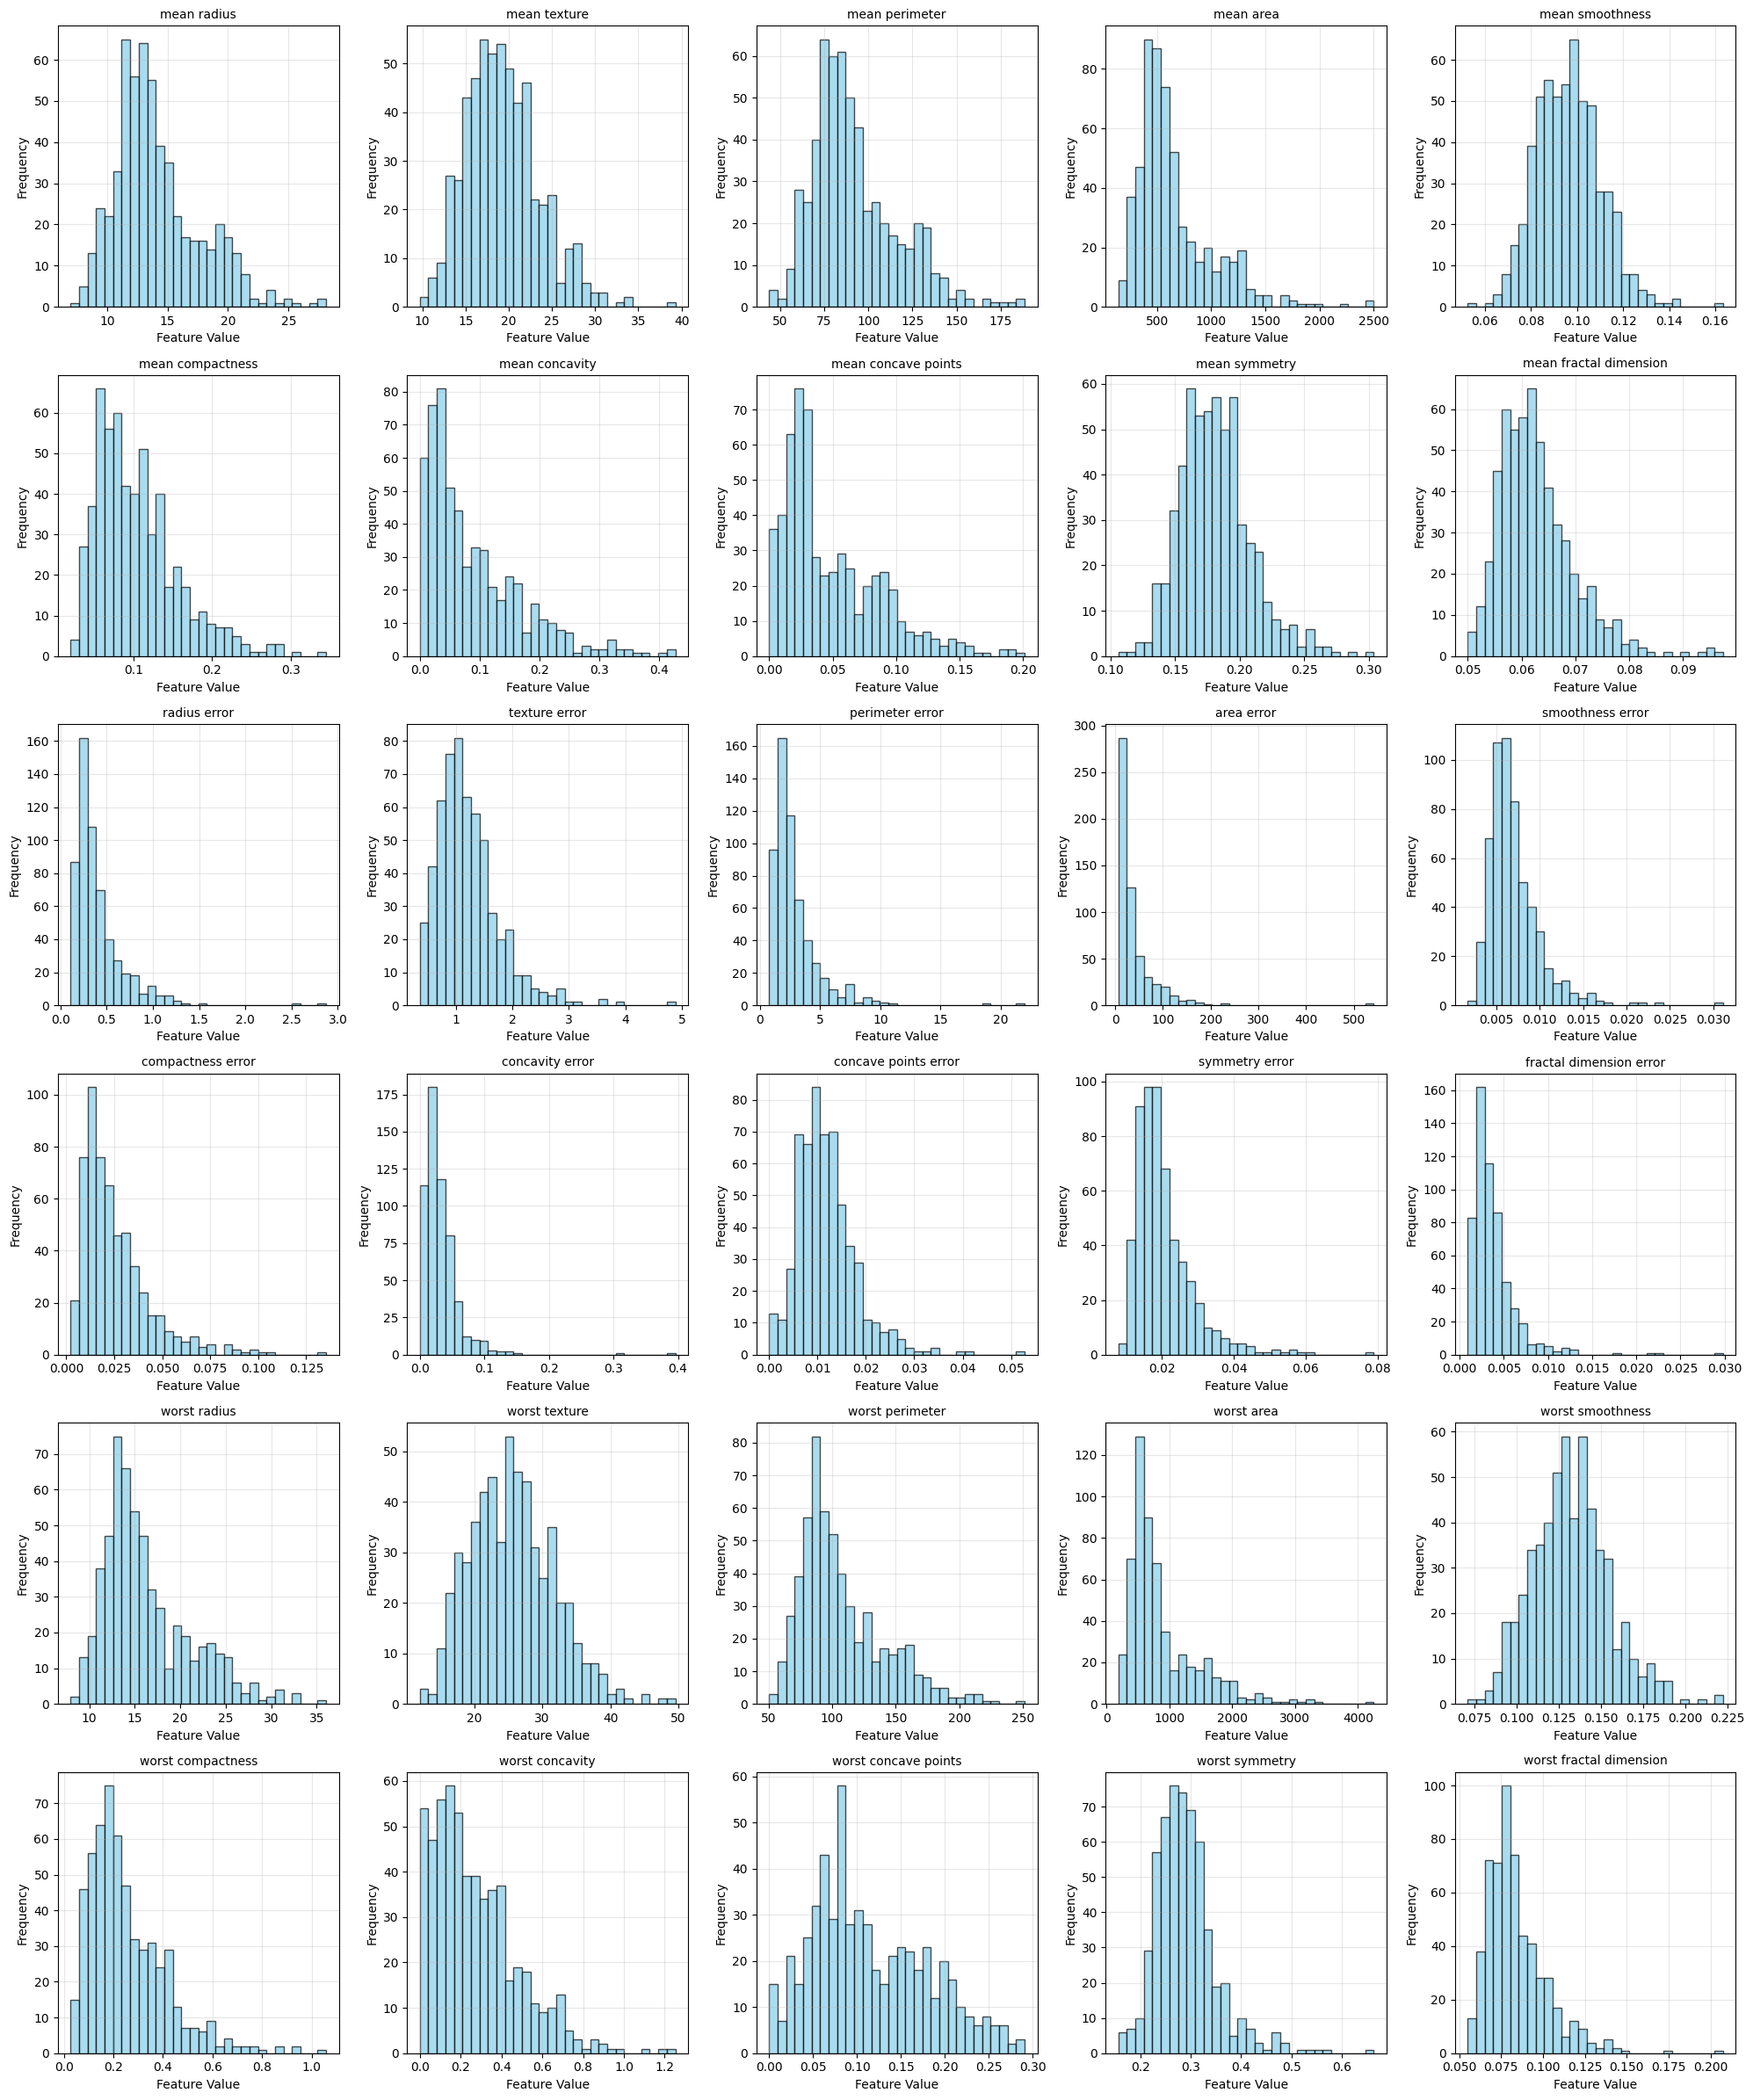

データセットの形状: (569, 30)
ターゲット変数の分布:
1    357
0    212
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 課題1：すべての特徴量のヒストグラムを作成する
plt.rcParams['axes.unicode_minus'] = False    # マイナス記号を正しく表示するため

# 6行5列のサブプロットを作成し、30個の特徴量のヒストグラムを表示する
fig, axes = plt.subplots(6, 5, figsize=(20, 24))
axes = axes.flatten()

# 各特徴量のヒストグラムを描画する
for i, feature in enumerate(breast['feature_names']):
    axes[i].hist(df[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'{feature}', fontsize=10)
    axes[i].set_xlabel('Feature Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# データセットの基本情報を表示する
print("データセットの形状:", df.shape)
print("ターゲット変数の分布:")
print(pd.Series(breast['target']).value_counts())


データセットに外れ値はなかったものとして、次のように、訓練データとテストデータに分割したとします。

問題２：  
特徴量を標準化したうえで、訓練データの全ての特徴量を用いて主成分分析を行ってください。その上で、横軸を新しい主成分のインデックス（０から２９まで）とした、寄与率および累積寄与率のグラフを作成してください。  
テストデータの標準化は、訓練データの統計量を使う事に注意してください。

Assuming that there were no outliers in the data set, suppose we split the data into training and test data as follows

Question 2:  
After standardizing the features, perform a principal component analysis using all the features in the training data. Then, create a graph of the contribution ratio and cumulative contribution ratio, with the horizontal axis as the index of the new principal component (from 0 to 29).  
Note that the standardization of the test data uses the statistics of the training data.

In [3]:
# トレーニングデータとテストデータに分割
from sklearn.model_selection import train_test_split
X = breast['data']
y = breast['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

標準化前の訓練データの形状: (398, 30)
標準化後の訓練データの形状: (398, 30)
標準化前の訓練データの平均値: [1.41855000e+01 1.91928392e+01 9.23355025e+01 6.61859045e+02
 9.64749497e-02]
標準化後の訓練データの平均値: [-2.26033597e-15 -1.38917353e-16  2.35657390e-15 -6.37680863e-16
 -1.38219977e-15]
PCA後の訓練データの形状: (398, 30)
主成分の数: 30
最初の10個の主成分の寄与率: [0.43689315 0.19415163 0.09661545 0.06716611 0.0549883  0.04012257
 0.02183068 0.01489226 0.01374108 0.01101371]
最初の10個の主成分の累積寄与率: [0.43689315 0.63104478 0.72766023 0.79482633 0.84981464 0.88993721
 0.91176789 0.92666015 0.94040123 0.95141495]


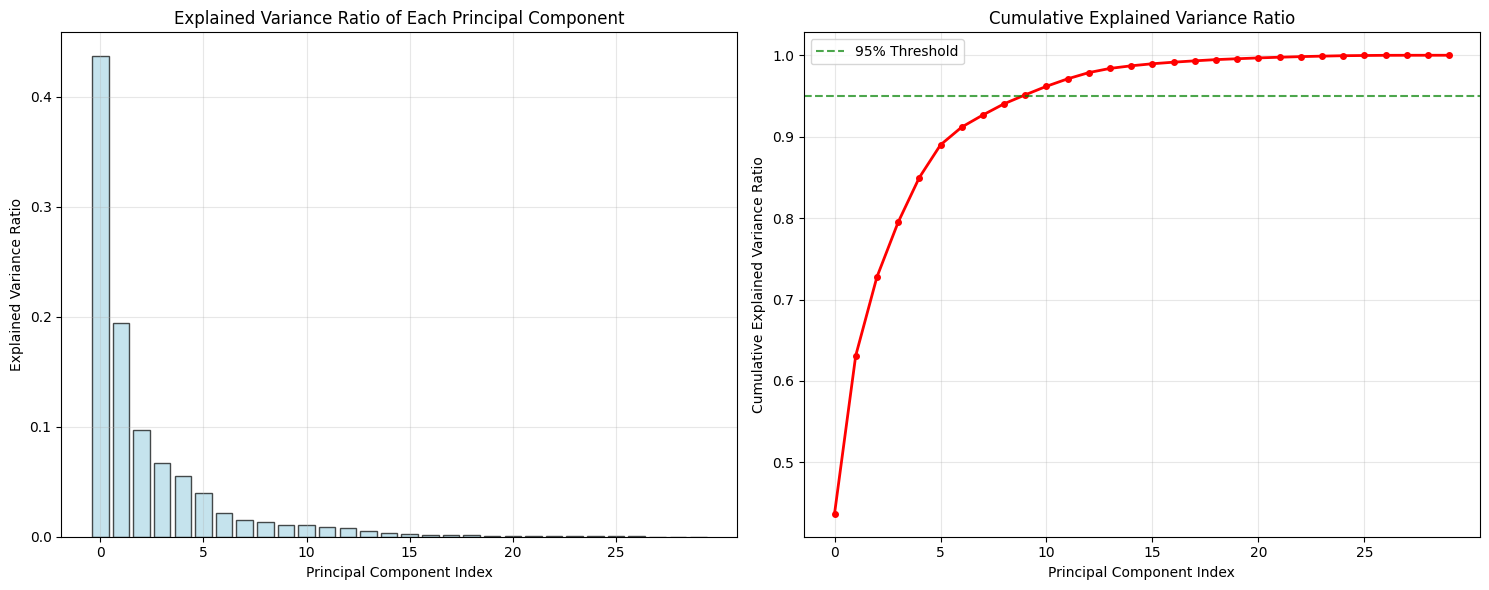

累積寄与率が95%に達するために必要な主成分の数: 10
最初の10個の主成分による累積寄与率: 0.9514


In [4]:
# 課題2：特徴量の標準化と主成分分析
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. 特徴量の標準化
# 訓練データを用いて標準化パラメータを計算する
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 訓練データの標準化
X_test_scaled = scaler.transform(X_test)        # テストデータは訓練データの統計量を用いて標準化する

print("標準化前の訓練データの形状:", X_train.shape)
print("標準化後の訓練データの形状:", X_train_scaled.shape)
print("標準化前の訓練データの平均値:", np.mean(X_train, axis=0)[:5])  # 最初の5つの特徴量の平均値を表示
print("標準化後の訓練データの平均値:", np.mean(X_train_scaled, axis=0)[:5])  # 0に近いはず

# 2. 主成分分析
# 30個すべての特徴量を用いてPCAを実行
pca = PCA(n_components=30)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA後の訓練データの形状:", X_train_pca.shape)
print("主成分の数:", pca.n_components_)

# 3. 寄与率と累積寄与率の計算
explained_variance_ratio = pca.explained_variance_ratio_  # 各主成分の寄与率
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)  # 累積寄与率

print("最初の10個の主成分の寄与率:", explained_variance_ratio[:10])
print("最初の10個の主成分の累積寄与率:", cumulative_variance_ratio[:10])

# 4. 寄与率と累積寄与率のグラフを描画
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 寄与率のグラフ
ax1.bar(range(30), explained_variance_ratio, alpha=0.7, color='lightblue', edgecolor='black')
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Explained Variance Ratio of Each Principal Component')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 30, 5))

# 累積寄与率のグラフ
ax2.plot(range(30), cumulative_variance_ratio, 'o-', color='red', linewidth=2, markersize=4)
ax2.set_xlabel('Principal Component Index')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
ax2.set_title('Cumulative Explained Variance Ratio')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 30, 5))
ax2.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% Threshold')
ax2.legend()

plt.tight_layout()
plt.show()

# 累積寄与率が95%に達するために必要な主成分の数を表示
components_for_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print(f"累積寄与率が95%に達するために必要な主成分の数: {components_for_95}")
print(f"最初の{components_for_95}個の主成分による累積寄与率: {cumulative_variance_ratio[components_for_95-1]:.4f}")

問題３：  
新しい主成分で、分析に使用する主成分の数を１から３０まで増やしていった時に、サポートベクトルマシンの正解率がどのように変化していくかをグラフ描画して確認してください。  
- 横軸を採用する主成分の数、縦軸を訓練データ、テストデータのそれぞれの正解率とするグラフを作成してください。
- サポートベクトルマシンは次を用いてください。：SVC(kernel='linear', random_state=0)  

Question 3:  
With the new principal components, check how the percentage of correct answers in the support vector machine changes as the number of principal components used in the analysis is increased from 1 to 30 by drawing a graph.  
- Create a graph with the number of principal components employed on the horizontal axis and the percentage of correct answers for the training and test data, respectively, on the vertical axis.
- For the support vector machine, use the following: SVC(kernel='linear', random_state=0)  



異なる主成分数におけるSVM分類性能の計算を開始します...
主成分数 | 訓練データ正解率 | テストデータ正解率
--------------------------------------------------
     1    |      0.9296      |      0.8947
     2    |      0.9598      |      0.9415
     3    |      0.9598      |      0.9298
     4    |      0.9698      |      0.9532
     5    |      0.9824      |      0.9708
    10    |      0.9849      |      0.9708
    15    |      0.9874      |      0.9649
    20    |      0.9874      |      0.9591
    25    |      0.9874      |      0.9591
    30    |      0.9874      |      0.9591
計算完了!


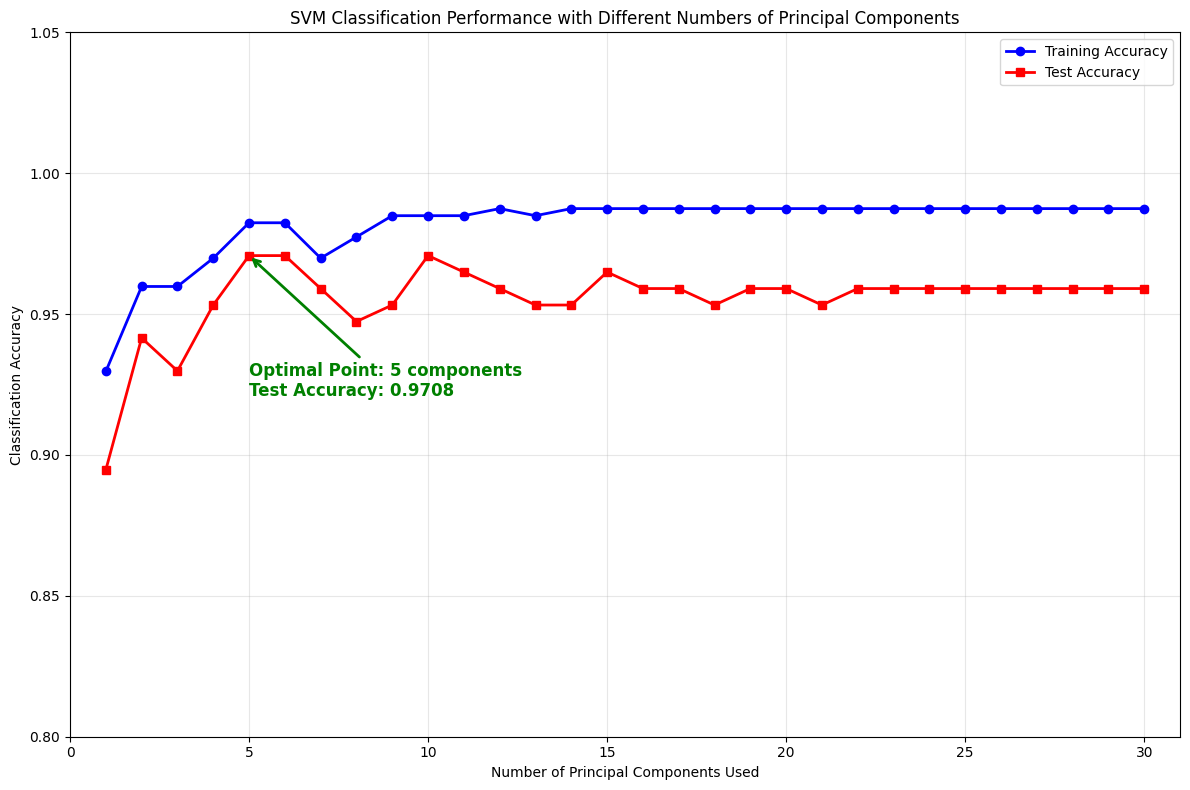


=== 分析結果 ===
最高のテストデータ正解率: 0.9708
最適な主成分数: 5
対応する訓練データ正解率: 0.9824

テストデータ正解率が0.95以上の主成分数:
  4個の主成分: 0.9532
  5個の主成分: 0.9708
  6個の主成分: 0.9708
  7個の主成分: 0.9591
  9個の主成分: 0.9532
  10個の主成分: 0.9708
  11個の主成分: 0.9649
  12個の主成分: 0.9591
  13個の主成分: 0.9532
  14個の主成分: 0.9532
  15個の主成分: 0.9649
  16個の主成分: 0.9591
  17個の主成分: 0.9591
  18個の主成分: 0.9532
  19個の主成分: 0.9591
  20個の主成分: 0.9591
  21個の主成分: 0.9532
  22個の主成分: 0.9591
  23個の主成分: 0.9591
  24個の主成分: 0.9591
  25個の主成分: 0.9591
  26個の主成分: 0.9591
  27個の主成分: 0.9591
  28個の主成分: 0.9591
  29個の主成分: 0.9591
  30個の主成分: 0.9591

性能比較:
全30個の主成分を使用 - 訓練正解率: 0.9874, テスト正解率: 0.9591
最適な5個の主成分を使用 - 訓練正解率: 0.9824, テスト正解率: 0.9708

過学習分析:
最大の過学習は1個の主成分で見られ、訓練とテストの正解率の差: 0.0349


In [5]:
# 課題3：異なる主成分数におけるSVM分類性能の分析
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 結果を保存するリストを初期化
n_components_list = range(1, 31)  # 主成分数は1から30まで
train_accuracies = []  # 訓練データの正解率
test_accuracies = []   # テストデータの正解率

print("異なる主成分数におけるSVM分類性能の計算を開始します...")
print("主成分数 | 訓練データ正解率 | テストデータ正解率")
print("-" * 50)

# 各主成分数について分析を行う
for n_comp in n_components_list:
    # 1. 最初のn_comp個の主成分を使用
    X_train_n = X_train_pca[:, :n_comp]  # 訓練データの最初のn_comp個の主成分
    X_test_n = X_test_pca[:, :n_comp]    # テストデータの最初のn_comp個の主成分
    
    # 2. SVM分類器を訓練
    svm_model = SVC(kernel='linear', random_state=0)
    svm_model.fit(X_train_n, y_train)
    
    # 3. 予測と正解率の計算
    y_train_pred = svm_model.predict(X_train_n)  # 訓練データの予測
    y_test_pred = svm_model.predict(X_test_n)    # テストデータの予測
    
    train_acc = accuracy_score(y_train, y_train_pred)  # 訓練データの正解率
    test_acc = accuracy_score(y_test, y_test_pred)     # テストデータの正解率
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # 5主成分ごとに結果を出力
    if n_comp % 5 == 0 or n_comp <= 5:
        print(f"    {n_comp:2d}    |      {train_acc:.4f}      |      {test_acc:.4f}")

print("計算完了!")

# 4. 正解率の変化をグラフで描画
plt.figure(figsize=(12, 8))
plt.plot(n_components_list, train_accuracies, 'o-', label='Training Accuracy', 
         color='blue', linewidth=2, markersize=6)
plt.plot(n_components_list, test_accuracies, 's-', label='Test Accuracy', 
         color='red', linewidth=2, markersize=6)

plt.xlabel('Number of Principal Components Used')
plt.ylabel('Classification Accuracy')
plt.title('SVM Classification Performance with Different Numbers of Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 31)
plt.ylim(0.8, 1.05)
plt.xticks(range(0, 31, 5))

# 最適点のマーカーを追加
max_test_acc_idx = np.argmax(test_accuracies)
max_test_acc = test_accuracies[max_test_acc_idx]
optimal_n_comp = n_components_list[max_test_acc_idx]

plt.annotate(f'Optimal Point: {optimal_n_comp} components\nTest Accuracy: {max_test_acc:.4f}', 
             xy=(optimal_n_comp, max_test_acc), xytext=(optimal_n_comp, max_test_acc - 0.05),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=12, color='green', weight='bold')

plt.tight_layout()
plt.show()

# 5. 分析結果の出力
print("\n=== 分析結果 ===")
print(f"最高のテストデータ正解率: {max_test_acc:.4f}")
print(f"最適な主成分数: {optimal_n_comp}")
print(f"対応する訓練データ正解率: {train_accuracies[max_test_acc_idx]:.4f}")

# テストデータ正解率が0.95を超える主成分数を探す
good_performance = [(i+1, acc) for i, acc in enumerate(test_accuracies) if acc >= 0.95]
if good_performance:
    print(f"\nテストデータ正解率が0.95以上の主成分数:")
    for n_comp, acc in good_performance:
        print(f"  {n_comp}個の主成分: {acc:.4f}")
else:
    print("\nテストデータ正解率が0.95以上に達する主成分数はありませんでした")

# 全30主成分を使用した場合と最適数の場合との性能比較
print(f"\n性能比較:")
print(f"全30個の主成分を使用 - 訓練正解率: {train_accuracies[-1]:.4f}, テスト正解率: {test_accuracies[-1]:.4f}")
print(f"最適な{optimal_n_comp}個の主成分を使用 - 訓練正解率: {train_accuracies[max_test_acc_idx]:.4f}, テスト正解率: {max_test_acc:.4f}")

# 過学習の分析
overfitting_analysis = []
for i, (train_acc, test_acc) in enumerate(zip(train_accuracies, test_accuracies)):
    diff = train_acc - test_acc
    overfitting_analysis.append((i+1, diff))

max_overfitting = max(overfitting_analysis, key=lambda x: x[1])
print(f"\n過学習分析:")
print(f"最大の過学習は{max_overfitting[0]}個の主成分で見られ、訓練とテストの正解率の差: {max_overfitting[1]:.4f}")